Install Packages

In [53]:
!pip install -qU langgraph langchain-groq langchain-core pandas

In [2]:
import os
import pandas as pd

from getpass import getpass
from typing import TypedDict, Literal

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

from langgraph.graph import StateGraph, END

API Key

In [4]:
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

Create LLM

In [7]:
llm = ChatGroq(model="llama-3.3-70b-versatile",temperature=0)

Upload CSV files

In [79]:
from google.colab import files

uploaded = files.upload()

donors_df = pd.read_csv("donors.csv")
ngos_df = pd.read_csv("ngos.csv")
volunteers_df = pd.read_csv("volunteers.csv")

Saving volunteers.csv to volunteers.csv
Saving ngos.csv to ngos.csv
Saving donors.csv to donors.csv


Check data

In [185]:
print(donors_df)

print()

print(ngos_df)

print()

print(volunteers_df)

         donor_name    food_name  quantity     location  expiry_hours
0         ABC Hotel  Veg Biryani        20      Chennai             4
1      Grand Palace   Lemon Rice        15   Coimbatore             3
2    Royal Caterers      Chapati       200      Madurai             2
3      Fresh Bakery        Bread        80        Salem            24
4  Green Restaurant    Curd Rice        10  Tirunelveli             5
5  Ocean View Hotel        Meals        30    Nagercoil             6

          ngo_name     location  capacity     status
0    Helping Hands      Chennai       500  available
1     Food For All   Coimbatore       300  available
2  Hope Foundation      Madurai       200  available
3      Smile Trust        Salem       250       busy
4     Care Mission  Tirunelveli       350  available
5     People First    Nagercoil       150  available

  volunteer_name     location status
0          Rahul      Chennai   busy
1          Priya   Coimbatore   free
2           Arun      Madu

Create State

In [186]:
class FoodState(TypedDict):
    donor_name: str
    food_name: str
    quantity: int
    location: str
    expiry_hours: int

    validation: str
    validation_reason: str

    priority: str
    priority_reason: str

    ngo: str
    volunteer: str
    status: str

Donation Intake Node

In [187]:
def donation_intake_node(state: FoodState) -> FoodState:

    print("\n======= Available Food Donations =======")

    for index, row in donors_df.iterrows():

        print(f"{index + 1}. {row['donor_name']} | "
              f"{row['food_name']} | "
              f"{row['location']}")

    choice = int(input("\nSelect Donation Number: "))

    selected = donors_df.iloc[choice - 1]

    print("\nSelected Donation")
    print(selected)

    return {

        "donor_name": selected["donor_name"],

        "food_name": selected["food_name"],

        "quantity": int(selected["quantity"]),

        "location": selected["location"],

        "expiry_hours": int(selected["expiry_hours"]),

        "validation": "",

        "validation_reason": "",

        "priority": "",

        "priority_reason": "",

        "ngo": "",

        "volunteer": "",

        "status": ""
    }

Agent 1 - Donation Validation Agent

In [188]:
VALIDATION_SYSTEM_PROMPT = """
You are an AI Food Donation Validation Agent.

Your responsibility is to decide whether donated food is suitable for redistribution.

Validation Rules:
1. Food should not be expired.
2. Expiry hours must be greater than 0.
3. Quantity must be greater than 0.
4. If the food appears safe and usable, approve it.
5. Otherwise reject it.

Respond ONLY in this format:

Status: APPROVED
Reason: Explain why the donation is safe.

OR

Status: REJECTED
Reason: Explain why the donation is rejected.

Keep the reason short (one sentence).
"""

Validation Agent Node

In [189]:
def validation_agent_node(state: FoodState) -> FoodState:

    user_message = f"""
Donor Name: {state['donor_name']}
Food Name: {state['food_name']}
Quantity: {state['quantity']}
Location: {state['location']}
Expiry Hours: {state['expiry_hours']}
"""

    response = llm.invoke([
        SystemMessage(content=VALIDATION_SYSTEM_PROMPT),
        HumanMessage(content=user_message)
    ])

    output = response.content.strip()

    print("\n===== Validation Agent =====")
    print(output)

    if "APPROVED" in output.upper():
        validation = "APPROVED"
    else:
        validation = "REJECTED"

    return {
    **state,
    "validation": validation,
    "validation_reason": output
}

Test Agent 1

In [190]:
test_state = {
    "donor_name": "ABC Hotel",
    "food_name": "Veg Biryani",
    "quantity": 20,
    "location": "Chennai",
    "expiry_hours": 4,

    "validation": "",
    "validation_reason": "",

    "priority": "",
    "priority_reason": "",

    "ngo": "",
    "volunteer": ""
}

result = validation_agent_node(test_state)

print("\nValidation Result:")
print(result)


===== Validation Agent =====
Status: APPROVED
Reason: The donated food has not expired and has a valid expiry time of 4 hours, making it safe for redistribution.

Validation Result:
{'donor_name': 'ABC Hotel', 'food_name': 'Veg Biryani', 'quantity': 20, 'location': 'Chennai', 'expiry_hours': 4, 'validation': 'APPROVED', 'validation_reason': 'Status: APPROVED\nReason: The donated food has not expired and has a valid expiry time of 4 hours, making it safe for redistribution.', 'priority': '', 'priority_reason': '', 'ngo': '', 'volunteer': ''}


Agent 2 - Priority Agent

In [191]:
PRIORITY_SYSTEM_PROMPT = """
You are an AI Priority Assessment Agent for food donations.

Your job is to assign a priority level.

Guidelines:

HIGH:
- Expiry <= 4 hours
- OR very large donation (100 or more meals)

MEDIUM:
- Expiry between 5 and 12 hours

LOW:
- Expiry greater than 12 hours

Respond ONLY in this format:

Priority: HIGH
Reason: <short reason>

OR

Priority: MEDIUM
Reason: <short reason>

OR

Priority: LOW
Reason: <short reason>
"""

Priority Agent Node

In [192]:
def priority_agent_node(state: FoodState) -> FoodState:

    user_message = f"""
Food Name: {state['food_name']}
Quantity: {state['quantity']}
Expiry Hours: {state['expiry_hours']}
"""

    response = llm.invoke([
        SystemMessage(content=PRIORITY_SYSTEM_PROMPT),
        HumanMessage(content=user_message)
    ])

    output = response.content.strip()

    print("\n===== Priority Agent =====")
    print(output)

    if "HIGH" in output.upper():
        priority = "HIGH"

    elif "MEDIUM" in output.upper():
        priority = "MEDIUM"

    else:
        priority = "LOW"

    return {
    **state,
    "priority": priority,
    "priority_reason": output
}

Test Agent 2

In [193]:
result = priority_agent_node(result)

print("\nPriority Result:")
print(result)


===== Priority Agent =====
Priority: HIGH
Reason: Expiry in 4 hours

Priority Result:
{'donor_name': 'ABC Hotel', 'food_name': 'Veg Biryani', 'quantity': 20, 'location': 'Chennai', 'expiry_hours': 4, 'validation': 'APPROVED', 'validation_reason': 'Status: APPROVED\nReason: The donated food has not expired and has a valid expiry time of 4 hours, making it safe for redistribution.', 'priority': 'HIGH', 'priority_reason': 'Priority: HIGH\nReason: Expiry in 4 hours', 'ngo': '', 'volunteer': ''}


Agent 3 – NGO Matching Agent

In [194]:
def ngo_matching_node(state: FoodState) -> FoodState:

    available_ngos = ngos_df[
        (ngos_df["location"].str.lower() == state["location"].lower()) &
        (ngos_df["status"] == "available")
    ]

    if not available_ngos.empty:

        ngo = available_ngos.iloc[0]["ngo_name"]

    else:

        ngo = "No NGO Available"

    print("\n===== NGO Matching Agent =====")
    print(f"Assigned NGO: {ngo}")

    return {
        **state,
        "ngo": ngo
    }

In [195]:
result = ngo_matching_node(result)

print(result)


===== NGO Matching Agent =====
Assigned NGO: Helping Hands
{'donor_name': 'ABC Hotel', 'food_name': 'Veg Biryani', 'quantity': 20, 'location': 'Chennai', 'expiry_hours': 4, 'validation': 'APPROVED', 'validation_reason': 'Status: APPROVED\nReason: The donated food has not expired and has a valid expiry time of 4 hours, making it safe for redistribution.', 'priority': 'HIGH', 'priority_reason': 'Priority: HIGH\nReason: Expiry in 4 hours', 'ngo': 'Helping Hands', 'volunteer': ''}


Agent 4 - Volunteer Assignment Agent

In [196]:
def volunteer_assignment_node(state: FoodState) -> FoodState:

    # If no NGO was assigned, don't assign a volunteer
    if state["ngo"] == "No NGO Available":
        volunteer = "Not Assigned"
        status = "Waiting for NGO"

    else:
        available = volunteers_df[
            (volunteers_df["location"].str.lower() == state["location"].lower()) &
            (volunteers_df["status"] == "free")
        ]

        if not available.empty:
            volunteer = available.iloc[0]["volunteer_name"]

            volunteers_df.loc[
                volunteers_df["volunteer_name"] == volunteer,
                "status"
            ] = "busy"

            status = "Volunteer Assigned"

        else:
            volunteer = "No Volunteer Available"
            status = "Waiting for Volunteer"

    print("\n===== Volunteer Assignment Agent =====")
    print(f"Assigned Volunteer: {volunteer}")

    return {
        **state,
        "volunteer": volunteer,
        "status": status
    }

In [197]:
result = volunteer_assignment_node(result)

print(result)


===== Volunteer Assignment Agent =====
Assigned Volunteer: No Volunteer Available
{'donor_name': 'ABC Hotel', 'food_name': 'Veg Biryani', 'quantity': 20, 'location': 'Chennai', 'expiry_hours': 4, 'validation': 'APPROVED', 'validation_reason': 'Status: APPROVED\nReason: The donated food has not expired and has a valid expiry time of 4 hours, making it safe for redistribution.', 'priority': 'HIGH', 'priority_reason': 'Priority: HIGH\nReason: Expiry in 4 hours', 'ngo': 'Helping Hands', 'volunteer': 'No Volunteer Available', 'status': 'Waiting for Volunteer'}


In [198]:
print(volunteers_df)

  volunteer_name     location status
0          Rahul      Chennai   busy
1          Priya   Coimbatore   free
2           Arun      Madurai   busy
3        Keerthi        Salem   busy
4        Vignesh  Tirunelveli   free
5         Anitha    Nagercoil   free


Agent 5 – Final Report Agent

In [199]:
def final_report_node(state: FoodState) -> FoodState:

    print("\n")
    print("=" * 50)
    print("        FOODFLOW AI - FINAL REPORT")
    print("=" * 50)

    print(f"Donor Name        : {state['donor_name']}")
    print(f"Food Name         : {state['food_name']}")
    print(f"Quantity          : {state['quantity']} Meals")
    print(f"Location          : {state['location']}")
    print(f"Expiry Hours      : {state['expiry_hours']}")

    print("\n----------- AI ANALYSIS -----------")

    print(f"Validation        : {state['validation']}")
    print(f"Validation Reason : {state['validation_reason']}")

    print()

    print(f"Priority          : {state['priority']}")
    print(f"Priority Reason   : {state['priority_reason']}")

    print("\n-------- RESOURCE ASSIGNMENT -------")

    print(f"Assigned NGO      : {state['ngo']}")
    print(f"Assigned Volunteer: {state['volunteer']}")

    print()

    print(f"Status            : {state['status']}")

    print("=" * 50)

    return state

In [200]:
result = final_report_node(result)



        FOODFLOW AI - FINAL REPORT
Donor Name        : ABC Hotel
Food Name         : Veg Biryani
Quantity          : 20 Meals
Location          : Chennai
Expiry Hours      : 4

----------- AI ANALYSIS -----------
Validation        : APPROVED
Validation Reason : Status: APPROVED
Reason: The donated food has not expired and has a valid expiry time of 4 hours, making it safe for redistribution.

Priority          : HIGH
Priority Reason   : Priority: HIGH
Reason: Expiry in 4 hours

-------- RESOURCE ASSIGNMENT -------
Assigned NGO      : Helping Hands
Assigned Volunteer: No Volunteer Available

Status            : Waiting for Volunteer


Create Graph

In [201]:
builder = StateGraph(FoodState)

In [202]:
builder.add_node("intake", donation_intake_node)

builder.add_node("validation", validation_agent_node)

builder.add_node("priority", priority_agent_node)

builder.add_node("ngo", ngo_matching_node)

builder.add_node("volunteer", volunteer_assignment_node)

builder.add_node("report", final_report_node)

In [203]:
builder.set_entry_point("intake")

In [204]:
builder.add_edge("intake", "validation")

builder.add_edge("validation", "priority")

builder.add_edge("priority", "ngo")

builder.add_edge("ngo", "volunteer")

builder.add_edge("volunteer", "report")

builder.add_edge("report", END)

In [205]:
graph = builder.compile()

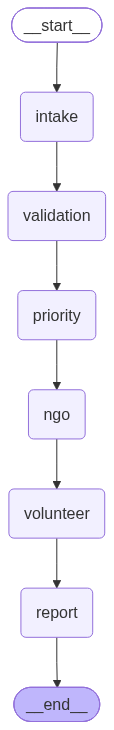

In [206]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

Run the Graph

In [207]:
final_state = graph.invoke({})


======= Available Food Donations =======
1. ABC Hotel | Veg Biryani | Chennai
2. Grand Palace | Lemon Rice | Coimbatore
3. Royal Caterers | Chapati | Madurai
4. Fresh Bakery | Bread | Salem
5. Green Restaurant | Curd Rice | Tirunelveli
6. Ocean View Hotel | Meals | Nagercoil

Select Donation Number: 4

Selected Donation
donor_name      Fresh Bakery
food_name              Bread
quantity                  80
location               Salem
expiry_hours              24
Name: 3, dtype: object

===== Validation Agent =====
Status: APPROVED
Reason: The bread has not expired, has a sufficient quantity, and has more than 0 expiry hours, making it safe for redistribution.

===== Priority Agent =====
Priority: LOW
Reason: Expiry greater than 12 hours

===== NGO Matching Agent =====
Assigned NGO: No NGO Available

===== Volunteer Assignment Agent =====
Assigned Volunteer: Not Assigned


        FOODFLOW AI - FINAL REPORT
Donor Name        : Fresh Bakery
Food Name         : Bread
Quantity          : 